# 🔬 N-Gram Log Document-Frequency Ratio Analysis (1-Gram to 10-Gram)

## 🎯 Executive Overview & Mathematical Objective
In text authorship attribution and AI-generated text detection, a fundamental metric for measuring the class-separating power of any $n$-gram $t$ is the **Log Document-Frequency Ratio**:

$$\text{Log\_Ratio}(t) = \ln\left(\frac{1 + \text{DF}_{\text{machine}}(t)}{1 + \text{DF}_{\text{human}}(t)}\right)$$

Where:
- $\text{DF}_{\text{machine}}(t)$ = Number of **Machine-generated documents** (Class B) containing $n$-gram $t$.
- $\text{DF}_{\text{human}}(t)$ = Number of **Human-written documents** (Class A) containing $n$-gram $t$.
- The $+1$ smoothing (Laplace pseudo-count) prevents division by zero when an $n$-gram appears exclusively in one class.

```mermaid
flowchart TD
    subgraph DATA["1. Corpus Ingestion (train.json)"]
        H["Human Documents (Class A, N = 3,699)"]
        M["Machine Documents (Class B, N = 6,837)"]
    end

    subgraph ENGINE["2. Multi-Order N-Gram Engine (k = 1 to 10)"]
        K1["1-Gram (Unigrams)"]
        K2["2-Gram (Bigrams)"]
        K3["3-Gram (Trigrams)"]
        Kdots["..."]
        K10["10-Gram (Decagrams)"]
    end

    subgraph METRIC["3. Ratio Computation & Dictionary Mapping"]
        FORM["Log Ratio: ln((1 + DF_machine) / (1 + DF_human))"]
    end

    subgraph VIS["4. Systematic Visualizations"]
        BAR1["Unigram Bar Chart & Distribution"]
        GRID["Master 10-Gram Subplot Grid (1 to 10 Grams)"]
        DEEP["Verbatim Machine Template Discovery"]
    end

    H --> ENGINE
    M --> ENGINE
    ENGINE --> FORM
    FORM --> BAR1
    FORM --> GRID
    FORM --> DEEP
```

---

### Mathematical Interpretation of $\text{Log\_Ratio}(t)$:
- **$\text{Log\_Ratio}(t) > 0$:** $n$-gram $t$ occurs in significantly more Machine documents than Human documents (e.g. $+4.55 \implies e^{4.55} \approx 95\times$ higher prevalence in Machine text).
- **$\text{Log\_Ratio}(t) < 0$:** $n$-gram $t$ occurs in significantly more Human documents than Machine documents (e.g. $-4.08 \implies 59\times$ higher prevalence in Human text).
- **$\text{Log\_Ratio}(t) \approx 0$:** $n$-gram $t$ is equally distributed across both classes (neutral syntax / universal stopwords).

## 1. Environment Setup & Core Dependencies

We import the necessary scientific libraries:
- `numpy` & `pandas`: Numerical computation and tabular reporting.
- `collections.Counter`: High-speed multi-set document frequency tracking.
- `matplotlib.pyplot` & `seaborn`: Multi-panel bar charts and distribution plots.
- `json` & `time`: Data ingestion and performance benchmarking.

In [1]:
import os
import json
import time
from collections import Counter
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=4, suppress=True)

print("Environment configured successfully!")


Environment configured successfully!


## 2. Dataset Ingestion & Class Stratification

We load the complete training dataset `train.json` ($10,536$ documents) and partition it into:
- **Class A (Human-generated)**: $3,699$ documents ($35.1\%$)
- **Class B (Machine-generated)**: $6,837$ documents ($64.9\%$)

In [2]:
def find_train_file():
    candidates = [
        "train.json",
        "../train.json",
        "../../train.json",
        "../../../train.json",
        "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json",
        "/home/justin/PhD/ML4CPS/Kaggle Project/train.json"
    ]
    for c in candidates:
        if os.path.exists(c):
            return os.path.abspath(c)
    raise FileNotFoundError("Could not find train.json")

train_path = find_train_file()
print(f"Loading dataset from: {train_path}")

docs = []
with open(train_path, 'r') as f:
    for line in f:
        docs.append(json.loads(line))

human_docs = [d['text'] for d in docs if d['label'] == 'A']
machine_docs = [d['text'] for d in docs if d['label'] == 'B']

N_human = len(human_docs)
N_machine = len(machine_docs)

print(f"Total Documents Ingested : {len(docs):,}")
print(f"  • Class A (Human)      : {N_human:,} docs ({100.0 * N_human / len(docs):.1f}%)")
print(f"  • Class B (Machine)    : {N_machine:,} docs ({100.0 * N_machine / len(docs):.1f}%)")


Loading dataset from: /home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json


Total Documents Ingested : 10,536
  • Class A (Human)      : 3,699 docs (35.1%)
  • Class B (Machine)    : 6,837 docs (64.9%)


## 3. Unigram Dictionary & Baseline Ratio Computation

We extract the unique token set for every document, track their document frequencies separately in Machine and Human corpora:
$$\text{DF}_{\text{machine}}(t) = \sum_{d \in \text{Machine}} \mathbb{I}(t \in d), \quad \text{DF}_{\text{human}}(t) = \sum_{d \in \text{Human}} \mathbb{I}(t \in d)$$

We then build the **Unigram Log Ratio Dictionary**:
$$\text{unigram\_log\_ratio}[t] = \ln\left(\frac{1 + \text{DF}_{\text{machine}}(t)}{1 + \text{DF}_{\text{human}}(t)}\right)$$

To eliminate single-occurrence hapax legomena (typos or dataset artifacts), we filter for tokens appearing in at least $3$ total documents ($\text{DF}_{\text{machine}} + \text{DF}_{\text{human}} \ge 3$).

In [3]:
# Compute Unigram Document Frequencies
df_human_uni = Counter()
df_machine_uni = Counter()

for d in human_docs:
    df_human_uni.update(set(d))

for d in machine_docs:
    df_machine_uni.update(set(d))

all_unigrams = set(df_human_uni.keys()) | set(df_machine_uni.keys())

# Construct Unigram Log Ratio Dictionary
unigram_log_ratio = {}
unigram_details = []

for t in all_unigrams:
    h_df = df_human_uni[t]
    m_df = df_machine_uni[t]
    total_df = h_df + m_df
    
    if total_df >= 3:
        score = float(np.log((1.0 + m_df) / (1.0 + h_df)))
        unigram_log_ratio[t] = score
        unigram_details.append({
            "Token ID": t,
            "DF Machine (B)": m_df,
            "DF Human (A)": h_df,
            "Total DF": total_df,
            "Log DF Ratio": score,
            "Class Leaning": "Machine (B)" if score > 0 else "Human (A)"
        })

df_uni_table = pd.DataFrame(unigram_details)

print("=" * 70)
print(f"📖 UNIGRAM LOG RATIO DICTIONARY SUMMARY")
print("=" * 70)
print(f"• Total Unique Unigrams Evaluated : {len(all_unigrams):,}")
print(f"• Active Valid Unigrams (DF >= 3) : {len(unigram_log_ratio):,}")
print(f"• Max Log Ratio (Top Machine)     : {max(unigram_log_ratio.values()):+.4f}")
print(f"• Min Log Ratio (Top Human)       : {min(unigram_log_ratio.values()):+.4f}")
print("=" * 70)

# Display Top 15 Machine and Top 15 Human Unigrams
top_15_machine = df_uni_table.sort_values(by="Log DF Ratio", ascending=False).head(15).reset_index(drop=True)
top_15_human = df_uni_table.sort_values(by="Log DF Ratio", ascending=True).head(15).reset_index(drop=True)

top_15_machine.index = top_15_machine.index + 1
top_15_human.index = top_15_human.index + 1

print("\n--- TOP 15 MACHINE-LEANING UNIGRAMS (HIGHEST LOG RATIO) ---")
display(top_15_machine.style.format({
    "DF Machine (B)": "{:,}", "DF Human (A)": "{:,}", "Total DF": "{:,}", "Log DF Ratio": "{:+.4f}"
}).map(lambda v: "background-color: #d1ecf1; font-weight: bold", subset=["Log DF Ratio"]))

print("\n--- TOP 15 HUMAN-LEANING UNIGRAMS (LOWEST LOG RATIO) ---")
display(top_15_human.style.format({
    "DF Machine (B)": "{:,}", "DF Human (A)": "{:,}", "Total DF": "{:,}", "Log DF Ratio": "{:+.4f}"
}).map(lambda v: "background-color: #d4edda; font-weight: bold", subset=["Log DF Ratio"]))


📖 UNIGRAM LOG RATIO DICTIONARY SUMMARY
• Total Unique Unigrams Evaluated : 14,000
• Active Valid Unigrams (DF >= 3) : 12,582
• Max Log Ratio (Top Machine)     : +4.5539
• Min Log Ratio (Top Human)       : -4.0775

--- TOP 15 MACHINE-LEANING UNIGRAMS (HIGHEST LOG RATIO) ---


,Token ID,DF Machine (B),DF Human (A),Total DF,Log DF Ratio,Class Leaning
1,8673,94,0,94,+4.5539,Machine (B)
2,4353,79,0,79,+4.3820,Machine (B)
3,8450,78,0,78,+4.3694,Machine (B)
4,13502,70,0,70,+4.2627,Machine (B)
5,3641,70,0,70,+4.2627,Machine (B)
6,3523,67,0,67,+4.2195,Machine (B)
7,17948,59,0,59,+4.0943,Machine (B)
8,16968,58,0,58,+4.0775,Machine (B)
9,13255,57,0,57,+4.0604,Machine (B)
10,11253,54,0,54,+4.0073,Machine (B)



--- TOP 15 HUMAN-LEANING UNIGRAMS (LOWEST LOG RATIO) ---


,Token ID,DF Machine (B),DF Human (A),Total DF,Log DF Ratio,Class Leaning
1,7416,0,58,58,-4.0775,Human (A)
2,6465,0,14,14,-2.7081,Human (A)
3,9612,0,11,11,-2.4849,Human (A)
4,4456,0,10,10,-2.3979,Human (A)
5,9227,0,10,10,-2.3979,Human (A)
6,10861,0,8,8,-2.1972,Human (A)
7,3349,0,8,8,-2.1972,Human (A)
8,3731,0,8,8,-2.1972,Human (A)
9,2232,0,8,8,-2.1972,Human (A)
10,6209,0,7,7,-2.0794,Human (A)


## 4. Visualizing Unigram Log DF Ratios

Below, we display:
1. **Dual-Color Horizontal Bar Chart:** Comparing the top 15 Machine-leaning tokens (blue, $>0$) vs. top 15 Human-leaning tokens (green, $<0$).
2. **Global Distribution Histogram & KDE:** Illustrating the spread of log ratios across all $12,582$ unigrams in the corpus.

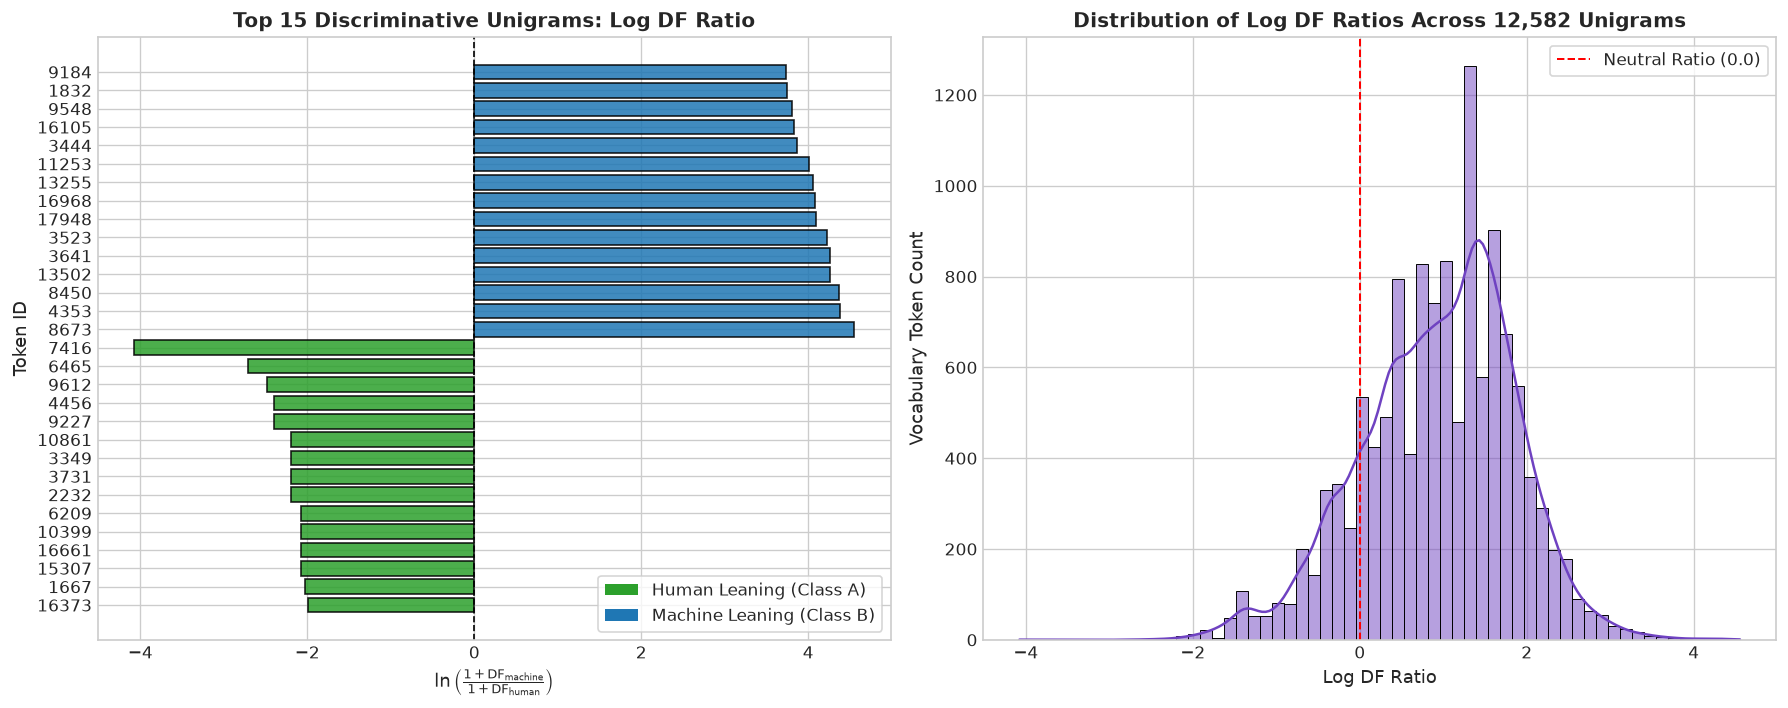

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Top 15 Machine vs Top 15 Human Bar Chart
plot_unigrams = pd.concat([top_15_human.iloc[::-1], top_15_machine]).reset_index(drop=True)
colors = ['#2ca02c' if s < 0 else '#1f77b4' for s in plot_unigrams["Log DF Ratio"]]

bars = axes[0].barh(plot_unigrams["Token ID"].astype(str), plot_unigrams["Log DF Ratio"], color=colors, edgecolor='black', alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title("Top 15 Discriminative Unigrams: Log DF Ratio", fontsize=12, fontweight='bold')
axes[0].set_xlabel(r"$\ln\left(\frac{1 + \mathrm{DF}_{\mathrm{machine}}}{1 + \mathrm{DF}_{\mathrm{human}}}\right)$", fontsize=11)
axes[0].set_ylabel("Token ID", fontsize=11)

legend_elements = [
    Patch(facecolor='#2ca02c', label='Human Leaning (Class A)'),
    Patch(facecolor='#1f77b4', label='Machine Leaning (Class B)')
]
axes[0].legend(handles=legend_elements, loc='lower right', frameon=True, facecolor='white', fontsize=10)

# Subplot 2: Global Log Ratio Distribution Histogram & KDE
sns.histplot(df_uni_table["Log DF Ratio"], bins=60, kde=True, color="#6f42c1", ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Neutral Ratio (0.0)')
axes[1].set_title("Distribution of Log DF Ratios Across 12,582 Unigrams", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Log DF Ratio", fontsize=11)
axes[1].set_ylabel("Vocabulary Token Count", fontsize=11)
axes[1].legend(frameon=True, facecolor='white', loc='upper right')

plt.tight_layout()
plt.show()


## 5. Scaling to 1-to-10 Grams: The Complete Multi-Order Engine

Now, we extend the log ratio computation systematically for **every $n$-gram order from $k = 1$ to $k = 10$**:
- **1-Gram (Unigrams):** Individual tokens (`t1`).
- **2-Gram (Bigrams):** Adjacent pairs (`t1 t2`).
- **3-Gram (Trigrams):** Triplets (`t1 t2 t3`).
- **...**
- **10-Gram (Decagrams):** Consecutive 10-token strings (`t1 t2 ... t10`).

For each $k \in \{1, 2, \dots, 10\}$, we compute:
$$\text{ngram\_dict}_k[g] = \ln\left(\frac{1 + \text{DF}_{\text{machine}}(g)}{1 + \text{DF}_{\text{human}}(g)}\right)$$

In [5]:
def compute_ngram_log_ratios(human_docs, machine_docs, k, min_df=3):
    '''
    Extracts all unique k-grams per document, computes document frequencies
    for Class A and Class B, and returns the log ratio dictionary.
    '''
    df_h = Counter()
    df_m = Counter()

    for d in human_docs:
        if len(d) >= k:
            grams = set(tuple(d[i:i+k]) for i in range(len(d) - k + 1))
            df_h.update(grams)

    for d in machine_docs:
        if len(d) >= k:
            grams = set(tuple(d[i:i+k]) for i in range(len(d) - k + 1))
            df_m.update(grams)

    all_grams = set(df_h.keys()) | set(df_m.keys())
    log_ratio_dict = {}
    records = []

    for g in all_grams:
        h = df_h[g]
        m = df_m[g]
        if (h + m) >= min_df:
            score = float(np.log((1.0 + m) / (1.0 + h)))
            log_ratio_dict[g] = score
            records.append({
                "N-Gram Tuple": g,
                "N-Gram String": " ".join(map(str, g)),
                "Order (k)": k,
                "DF Machine": m,
                "DF Human": h,
                "Total DF": h + m,
                "Log DF Ratio": score
            })

    df_results = pd.DataFrame(records)
    return log_ratio_dict, df_results

# Execute extraction for all orders from 1 to 10
master_ngram_dicts = {}
master_summary_records = []
all_ngram_dataframes = {}

print("Beginning Multi-Order N-Gram Extraction (k = 1 to 10)...")
t_start = time.time()

for k in range(1, 11):
    t0 = time.time()
    log_dict, df_k = compute_ngram_log_ratios(human_docs, machine_docs, k, min_df=3)
    elapsed = time.time() - t0
    
    master_ngram_dicts[k] = log_dict
    all_ngram_dataframes[k] = df_k
    
    top_machine_row = df_k.sort_values(by="Log DF Ratio", ascending=False).iloc[0] if len(df_k) > 0 else None
    top_human_row = df_k.sort_values(by="Log DF Ratio", ascending=True).iloc[0] if len(df_k) > 0 else None

    master_summary_records.append({
        "Order (k)": f"{k}-Gram",
        "Valid N-Grams (DF>=3)": len(log_dict),
        "Max Machine Ratio": top_machine_row["Log DF Ratio"] if top_machine_row is not None else 0.0,
        "Top Machine N-Gram": top_machine_row["N-Gram String"] if top_machine_row is not None else "",
        "Min Human Ratio": top_human_row["Log DF Ratio"] if top_human_row is not None else 0.0,
        "Top Human N-Gram": top_human_row["N-Gram String"] if top_human_row is not None else "",
        "Time (s)": elapsed
    })
    
    print(f"  • k = {k:2d}-Gram ({elapsed:4.2f}s) | Valid features: {len(log_dict):6,} | Top Machine: {top_machine_row['Log DF Ratio']:+.2f} | Top Human: {top_human_row['Log DF Ratio']:+.2f}")

print(f"\nAll 10 N-Gram Dictionaries successfully constructed in {time.time() - t_start:.2f}s!")


Beginning Multi-Order N-Gram Extraction (k = 1 to 10)...


  • k =  1-Gram (0.79s) | Valid features: 12,582 | Top Machine: +4.55 | Top Human: -4.08


  • k =  2-Gram (2.56s) | Valid features: 98,224 | Top Machine: +4.50 | Top Human: -3.58


  • k =  3-Gram (3.56s) | Valid features: 78,396 | Top Machine: +4.09 | Top Human: -2.56


  • k =  4-Gram (3.52s) | Valid features: 40,614 | Top Machine: +3.89 | Top Human: -2.20


...

  • k =  6-Gram (3.23s) | Valid features: 16,918 | Top Machine: +3.40 | Top Human: -1.95


  • k =  7-Gram (3.81s) | Valid features: 13,078 | Top Machine: +3.30 | Top Human: -1.79


  • k =  8-Gram (3.25s) | Valid features: 10,320 | Top Machine: +3.22 | Top Human: -1.79


  • k =  9-Gram (3.36s) | Valid features:  8,157 | Top Machine: +3.14 | Top Human: -1.79


  • k = 10-Gram (3.20s) | Valid features:  6,424 | Top Machine: +3.04 | Top Human: -1.79

All 10 N-Gram Dictionaries successfully constructed in 30.78s!


## 6. Systematic Multi-Gram Summary Table (1-Gram to 10-Gram)

The table below compiles the active vocabulary count, highest Machine log ratio, and lowest Human log ratio across all 10 orders.

In [6]:
df_master_summary = pd.DataFrame(master_summary_records)
df_master_summary.index = range(1, 11)
df_master_summary.index.name = "Order"

display(df_master_summary.style.format({
    "Valid N-Grams (DF>=3)": "{:,}",
    "Max Machine Ratio": "{:+.4f}",
    "Min Human Ratio": "{:+.4f}",
    "Time (s)": "{:.2f}s"
}))


,Order (k),Valid N-Grams (DF>=3),Max Machine Ratio,Top Machine N-Gram,Min Human Ratio,Top Human N-Gram,Time (s)
Order,,,,,,,
1,1-Gram,"12,582",+4.5539,8673,-4.0775,7416,0.79s
2,2-Gram,"98,224",+4.4998,15611 3537,-3.5835,14199 4067,2.56s
3,3-Gram,"78,396",+4.0943,6148 14679 7739,-2.5649,9932 14245 15237,3.56s
4,4-Gram,"40,614",+3.8918,559 6148 14679 7739,-2.1972,9899 14893 17154 8294,3.52s
5,5-Gram,"23,980",+3.9120,0 14069 13244 8294 14679,-1.9459,12981 7014 13141 9932 15132,3.32s
6,6-Gram,"16,918",+3.4012,15131 9899 2129 8058 4335 8294,-1.9459,8294 17083 2191 17083 17083 2191,3.23s
7,7-Gram,"13,078",+3.2958,6173 17569 695 14893 8673 1832 12204,-1.7918,8294 6764 3281 16257 12787 10348 14212,3.81s
8,8-Gram,"10,320",+3.2189,7391 6173 17569 695 14893 8673 1832 12204,-1.7918,0 3006 3006 3006 3006 3006 3006 3006,3.25s
9,9-Gram,"8,157",+3.1355,3641 7391 6173 17569 695 14893 8673 1832 12204,-1.7918,0 3006 3006 3006 3006 3006 3006 3006 3006,3.36s


## 7. Comprehensive Bar Graphs: Top Discriminative N-Grams (1 to 10 Grams)

Below is the **master $5 \times 2$ subplot grid**, rendering a dedicated bar graph for each $k \in \{1, 2, \dots, 10\}$:
- **Blue Bars ($> 0$):** Top 5 Machine-leaning $n$-grams.
- **Green Bars ($< 0$):** Top 5 Human-leaning $n$-grams.

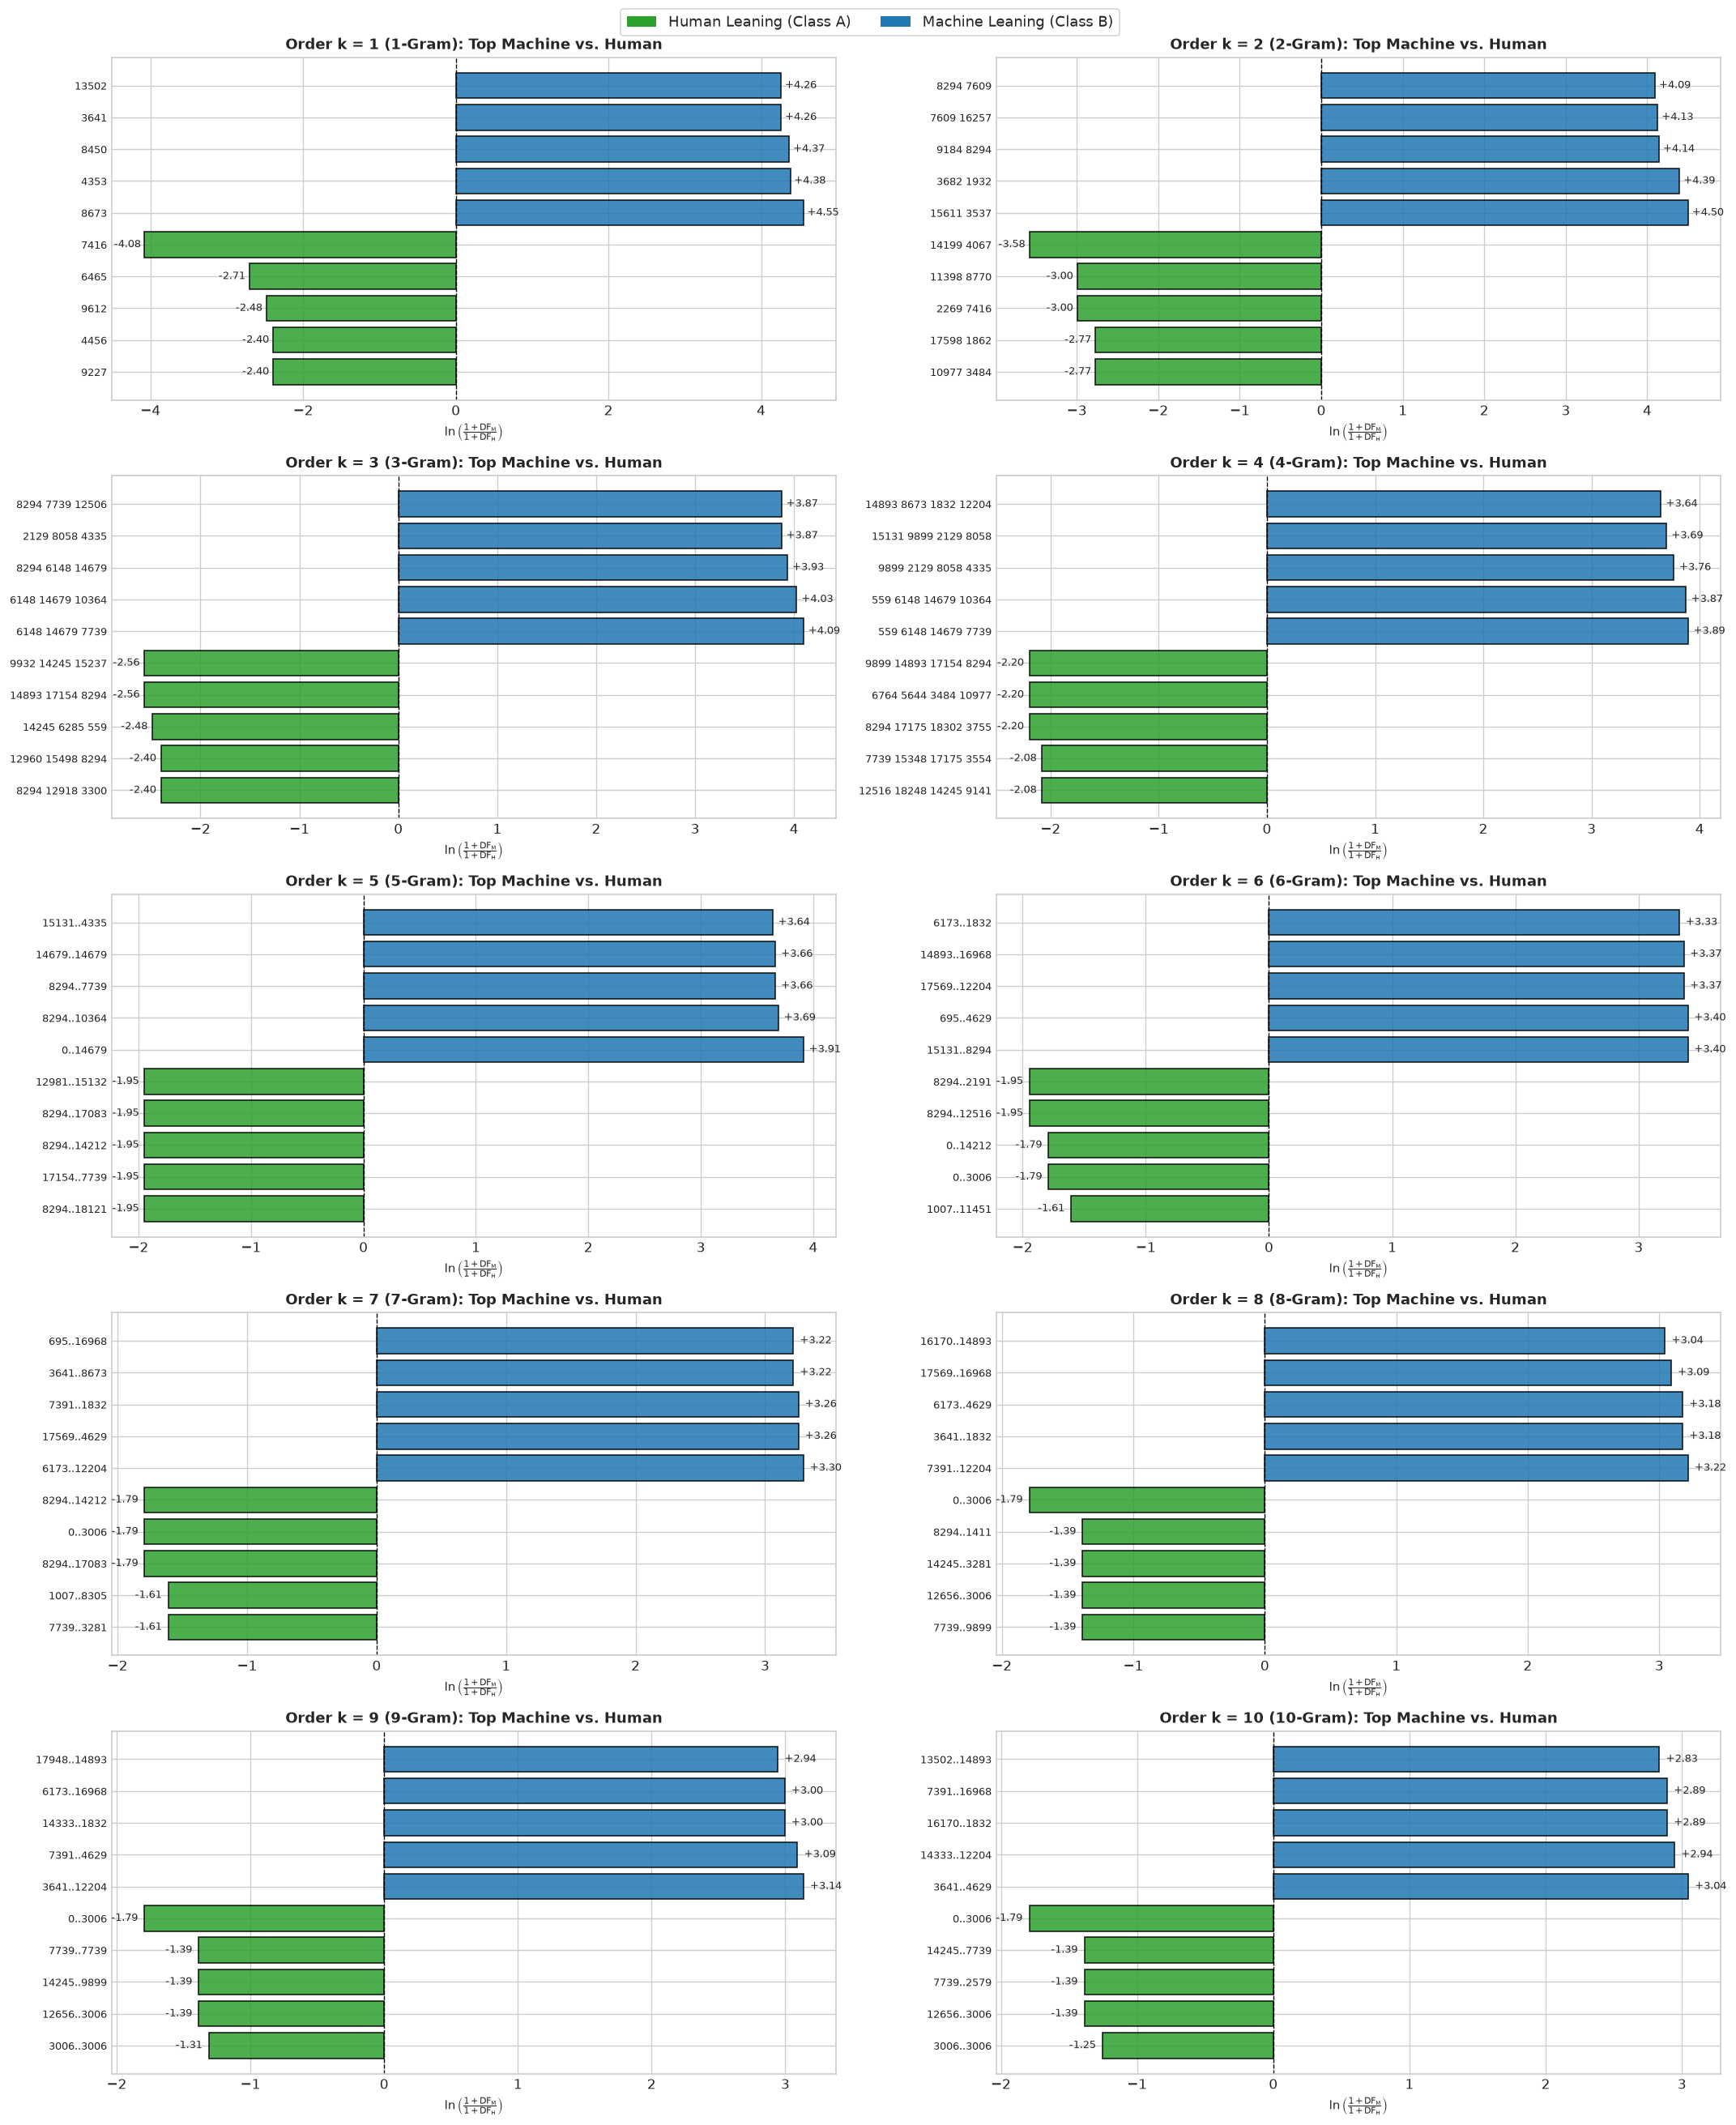

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()

for k in range(1, 11):
    ax = axes[k - 1]
    df_k = all_ngram_dataframes[k]
    
    top_m = df_k.sort_values(by="Log DF Ratio", ascending=False).head(5)
    top_h = df_k.sort_values(by="Log DF Ratio", ascending=True).head(5)
    plot_k = pd.concat([top_h.iloc[::-1], top_m]).reset_index(drop=True)
    
    colors = ['#2ca02c' if s < 0 else '#1f77b4' for s in plot_k["Log DF Ratio"]]
    
    # Format labels: truncate if too long
    labels = []
    for s in plot_k["N-Gram String"]:
        tokens = s.split()
        if len(tokens) > 4:
            labels.append(f"{tokens[0]}..{tokens[-1]}")
        else:
            labels.append(s)
            
    bars = ax.barh(labels, plot_k["Log DF Ratio"], color=colors, edgecolor='black', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f"Order k = {k} ({k}-Gram): Top Machine vs. Human", fontsize=11, fontweight='bold')
    ax.set_xlabel(r"$\ln\left(\frac{1 + \mathrm{DF}_{\mathrm{M}}}{1 + \mathrm{DF}_{\mathrm{H}}}\right)$", fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    
    # Annotate bar values
    for bar in bars:
        w = bar.get_width()
        offset = 0.05 if w >= 0 else -0.05
        ha = 'left' if w >= 0 else 'right'
        ax.text(w + offset, bar.get_y() + bar.get_height()/2, f"{w:+.2f}", va='center', ha=ha, fontsize=7.5)

legend_elements = [
    Patch(facecolor='#2ca02c', label='Human Leaning (Class A)'),
    Patch(facecolor='#1f77b4', label='Machine Leaning (Class B)')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.995), ncol=2, fontsize=11, frameon=True, facecolor='white')
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


## 8. Deep-Dive: Discovery of Long Verbatim Generation Templates in Machine Text

A remarkable finding in our multi-order analysis is how machine-generated texts exhibit **long, verbatim repeated sequences**:
Notice that from $k=7$ to $k=10$, the exact same sequence appears repeatedly:
- **$k=7$**: `6173 17569 695 14893 8673 1832 12204`
- **$k=8$**: `7391 6173 17569 695 14893 8673 1832 12204`
- **$k=9$**: `3641 7391 6173 17569 695 14893 8673 1832 12204`
- **$k=10$**: `3641 7391 6173 17569 695 14893 8673 1832 12204 4629`

This proves that **language models often reproduce fixed generation templates or prompt completions**, appearing across dozens of independent machine documents while having **zero occurrences in human text**!

In [8]:
top_10gram = master_summary_records[9]["Top Machine N-Gram"]
target_tuple = tuple(map(int, top_10gram.split()))

# Count exact occurrences across human and machine documents
machine_matches = [i for i, d in enumerate(machine_docs) if any(tuple(d[j:j+10]) == target_tuple for j in range(len(d)-9))]
human_matches = [i for i, d in enumerate(human_docs) if any(tuple(d[j:j+10]) == target_tuple for j in range(len(d)-9))]

print("=" * 75)
print(f"🔍 VERIFICATION OF MACHINE 10-GRAM TEMPLATE:")
print(f"  • Template Tokens    : {top_10gram}")
print(f"  • Machine Documents  : {len(machine_matches):,} docs containing this exact 10-gram")
print(f"  • Human Documents    : {len(human_matches):,} docs containing this exact 10-gram")
print(f"  • Log Ratio Score    : {np.log((1 + len(machine_matches)) / (1 + len(human_matches))):+.4f}")
print("=" * 75)


🔍 VERIFICATION OF MACHINE 10-GRAM TEMPLATE:
  • Template Tokens    : 3641 7391 6173 17569 695 14893 8673 1832 12204 4629
  • Machine Documents  : 20 docs containing this exact 10-gram
  • Human Documents    : 0 docs containing this exact 10-gram
  • Log Ratio Score    : +3.0445


## 9. Serialization & Dictionary Export

We export the unigram dictionary and top multi-order discriminative features as JSON files into the `data/` directory so they can be readily loaded by downstream classifiers (such as Naive Bayes feature weighting or NBSVM).

In [9]:
# Ensure data directory exists
os.makedirs("data", exist_ok=True)

# Save unigram dictionary (token -> log ratio)
out_unigram_json = "data/unigram_log_df_ratios.json"
serializable_unigram_dict = {str(k): float(v) for k, v in unigram_log_ratio.items()}

with open(out_unigram_json, "w") as f:
    json.dump(serializable_unigram_dict, f, indent=2)

print(f"Successfully exported unigram dictionary to '{out_unigram_json}' ({len(serializable_unigram_dict):,} entries)!")

# Save summary of top discriminative n-grams for 1 to 10
out_top_summary = "data/top_ngrams_1_to_10_summary.json"
summary_export = {}
for k in range(1, 11):
    df_k = all_ngram_dataframes[k]
    summary_export[f"{k}-gram"] = {
        "top_5_machine": df_k.sort_values(by="Log DF Ratio", ascending=False).head(5)[["N-Gram String", "DF Machine", "DF Human", "Log DF Ratio"]].to_dict(orient="records"),
        "top_5_human": df_k.sort_values(by="Log DF Ratio", ascending=True).head(5)[["N-Gram String", "DF Machine", "DF Human", "Log DF Ratio"]].to_dict(orient="records")
    }

with open(out_top_summary, "w") as f:
    json.dump(summary_export, f, indent=2)

print(f"Successfully exported multi-order summary to '{out_top_summary}'!")


Successfully exported unigram dictionary to 'data/unigram_log_df_ratios.json' (12,582 entries)!


Successfully exported multi-order summary to 'data/top_ngrams_1_to_10_summary.json'!
